# 01 — Data Collection

Сбор всех данных для проекта EquiSense:
- OHLCV (исторические цены)
- Фундаментальные показатели
- Финансовые новости

Источник: **yfinance** (бесплатно, без API ключей)

Данные сохраняются в `data/raw/` в формате Parquet и CSV.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime

# Пути
ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw data directory: {RAW_DIR}")

Raw data directory: /Users/dvank1mang1/EquiSense/data/raw


## 1. Список тикеров

In [2]:
TICKERS = [
    # Tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
    "ORCL", "CRM", "ADBE", "AMD", "INTC", "QCOM", "TXN",
    # Finance
    "JPM", "BAC", "GS", "MS", "WFC", "BLK", "AXP",
    # Healthcare
    "JNJ", "UNH", "PFE", "ABT", "MRK", "TMO",
    # Consumer
    "WMT", "HD", "MCD", "KO", "PG", "COST", "NKE",
    # Energy
    "XOM", "CVX",
    # Industrial
    "CAT", "BA", "HON",
    # Telecom / Media
    "T", "VZ", "DIS",
    # Visa / Payments
    "V", "MA",
]

# Макро-инструменты (ETF + индексы)
MACRO_TICKERS = {
    "SPY":  "S&P 500 ETF",
    "QQQ":  "NASDAQ-100 ETF",
    "^VIX": "Volatility Index",
    "TLT":  "20Y US Treasury ETF",
    "GLD":  "Gold ETF",
    "DX-Y.NYB": "US Dollar Index",
    "XLK":  "Tech Sector ETF",
    "XLF":  "Financial Sector ETF",
    "XLE":  "Energy Sector ETF",
    "XLV":  "Healthcare Sector ETF",
}

PERIOD   = "5y"
INTERVAL = "1d"

print(f"Тикеров акций: {len(TICKERS)}")
print(f"Макро-инструментов: {len(MACRO_TICKERS)}")
print(f"Период: {PERIOD}, интервал: {INTERVAL}")

Тикеров акций: 44
Макро-инструментов: 10
Период: 5y, интервал: 1d


## 2. Загрузка OHLCV данных

In [3]:
def fetch_ohlcv(ticker: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    """Загружает дневные OHLCV данные через yfinance."""
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval, auto_adjust=True)
    
    if df.empty:
        print(f"  [!] {ticker}: пустой датафрейм")
        return df
    
    # Нормализуем колонки
    df.index = pd.to_datetime(df.index).tz_localize(None)  # убираем timezone
    df.index.name = "date"
    df.columns = df.columns.str.lower()
    df = df[["open", "high", "low", "close", "volume"]]
    df = df.dropna()
    
    return df


# Загружаем все тикеры
ohlcv_data = {}

for ticker in TICKERS:
    print(f"Загружаю {ticker}...", end=" ")
    df = fetch_ohlcv(ticker, period=PERIOD, interval=INTERVAL)
    
    if not df.empty:
        ohlcv_data[ticker] = df
        # Сохраняем
        out_path = RAW_DIR / f"{ticker}_ohlcv.parquet"
        df.to_parquet(out_path)
        print(f"OK — {len(df)} строк [{df.index[0].date()} → {df.index[-1].date()}]")
    else:
        print("ПРОПУЩЕН")

print(f"\nЗагружено тикеров: {len(ohlcv_data)}/{len(TICKERS)}")

Загружаю AAPL... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю MSFT... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю GOOGL... OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю AMZN... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю NVDA... OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю META... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю TSLA... 

...

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю VZ... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю DIS... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю V... 

OK — 1255 строк [2021-04-01 → 2026-03-31]
Загружаю MA... 

OK — 1255 строк [2021-04-01 → 2026-03-31]

Загружено тикеров: 44/44


In [4]:
# Быстрый просмотр AAPL
ohlcv_data["AAPL"].tail(10)

,open,high,low,close,volume
date,,,,,
2026-03-18,252.630005,254.940002,249.000000,249.940002,35757900
2026-03-19,249.399994,251.830002,247.300003,248.960007,34864100
2026-03-20,247.979996,249.199997,246.000000,247.990005,88331100
2026-03-23,253.970001,254.600006,250.279999,251.490005,40546100
2026-03-24,250.350006,254.830002,249.550003,251.639999,45152300
2026-03-25,254.100006,255.000000,251.600006,252.619995,28476700
2026-03-26,252.119995,257.000000,250.770004,252.889999,41796700
2026-03-27,253.899994,255.490005,248.070007,248.800003,47900000
2026-03-30,250.070007,250.869995,245.509995,246.630005,39446200


In [5]:
# Статистика по загруженным данным
summary = []
for ticker, df in ohlcv_data.items():
    summary.append({
        "ticker": ticker,
        "rows": len(df),
        "start": df.index[0].date(),
        "end": df.index[-1].date(),
        "missing_%": round(df.isnull().mean().mean() * 100, 2),
        "last_close": round(df["close"].iloc[-1], 2),
    })

pd.DataFrame(summary).set_index("ticker")

,rows,start,end,missing_%,last_close
ticker,,,,,
AAPL,1255,2021-04-01,2026-03-31,0.0,253.79
MSFT,1255,2021-04-01,2026-03-31,0.0,370.17
GOOGL,1255,2021-04-01,2026-03-31,0.0,287.56
AMZN,1255,2021-04-01,2026-03-31,0.0,208.27
NVDA,1255,2021-04-01,2026-03-31,0.0,174.40
META,1255,2021-04-01,2026-03-31,0.0,572.13
TSLA,1255,2021-04-01,2026-03-31,0.0,371.75
ORCL,1255,2021-04-01,2026-03-31,0.0,147.11
CRM,1255,2021-04-01,2026-03-31,0.0,186.67


## 3. Фундаментальные данные

In [6]:
FUNDAMENTAL_FIELDS = {
    "trailingPE":        "pe_ratio",
    "trailingEps":       "eps",
    "returnOnEquity":    "roe",
    "debtToEquity":      "debt_to_equity",
    "revenueGrowth":     "revenue_growth",
    "marketCap":         "market_cap",
    "dividendYield":     "dividend_yield",
    "priceToBook":       "price_to_book",
    "earningsGrowth":    "earnings_growth",
    "currentRatio":      "current_ratio",
    "grossMargins":      "gross_margin",
    "operatingMargins":  "operating_margin",
    "shortName":         "name",
    "sector":            "sector",
    "industry":          "industry",
}


def fetch_fundamentals(ticker: str) -> dict:
    """Получает фундаментальные показатели компании."""
    stock = yf.Ticker(ticker)
    info = stock.info
    
    result = {"ticker": ticker, "fetched_at": datetime.now().isoformat()}
    for yf_field, our_field in FUNDAMENTAL_FIELDS.items():
        result[our_field] = info.get(yf_field)
    
    return result


# Загружаем
fundamentals = []

for ticker in TICKERS:
    print(f"Фундаментал {ticker}...", end=" ")
    try:
        data = fetch_fundamentals(ticker)
        fundamentals.append(data)
        print(f"OK — P/E: {data.get('pe_ratio')}, ROE: {data.get('roe')}")
    except Exception as e:
        print(f"ОШИБКА: {e}")

# Сохраняем
fund_df = pd.DataFrame(fundamentals).set_index("ticker")
fund_df.to_parquet(RAW_DIR / "fundamentals.parquet")
fund_df.to_csv(RAW_DIR / "fundamentals.csv")
print(f"\nСохранено: data/raw/fundamentals.parquet")

Фундаментал AAPL... 

OK — P/E: 32.16603, ROE: 1.5202099
Фундаментал MSFT... 

OK — P/E: 23.179087, ROE: 0.34390998
Фундаментал GOOGL... 

OK — P/E: 26.625925, ROE: 0.35705003
Фундаментал AMZN... 

OK — P/E: 29.04742, ROE: 0.22286
Фундаментал NVDA... 

...

OK — P/E: 9.536184, ROE: 0.18805
Фундаментал VZ... 

OK — P/E: 12.364532, ROE: 0.17069
Фундаментал DIS... 

OK — P/E: 14.194404, ROE: 0.12024
Фундаментал V... 

OK — P/E: 28.35272, ROE: 0.53954
Фундаментал MA... 

OK — P/E: 30.282425, ROE: 2.09915

Сохранено: data/raw/fundamentals.parquet


In [7]:
# Просмотр фундаментальных данных
fund_df[["name", "sector", "pe_ratio", "eps", "roe", "debt_to_equity", "revenue_growth", "market_cap"]]

,name,sector,pe_ratio,eps,roe,debt_to_equity,revenue_growth,market_cap
ticker,,,,,,,,
AAPL,Apple Inc.,Technology,32.166030,7.89,1.52021,102.630,0.157,3730186436608
MSFT,Microsoft Corporation,Technology,23.179087,15.97,0.34391,31.539,0.167,2751243485184
GOOGL,Alphabet Inc.,Communication Services,26.625925,10.80,0.35705,16.133,0.180,3478613393408
AMZN,"Amazon.com, Inc.",Consumer Cyclical,29.047420,7.17,0.22286,43.435,0.136,2235761950720
NVDA,NVIDIA Corporation,Technology,35.519350,4.91,1.01485,7.255,0.732,4238791933952
META,"Meta Platforms, Inc.",Communication Services,24.356321,23.49,0.30238,39.164,0.238,1447234633728
TSLA,"Tesla, Inc.",Consumer Cyclical,347.429900,1.07,0.04925,17.763,-0.031,1394966528000
ORCL,Oracle Corporation,Technology,26.411130,5.57,0.57572,415.265,0.217,423095140352
CRM,"Salesforce, Inc.",Technology,23.901410,7.81,0.12396,29.947,0.121,174909784064


## 4. Финансовые новости

In [8]:
def fetch_news(ticker: str, max_items: int = 50) -> list[dict]:
    """Получает последние новости по тикеру через yfinance."""
    stock = yf.Ticker(ticker)
    
    news_raw = stock.news or []
    
    news = []
    for item in news_raw[:max_items]:
        content = item.get("content", {})
        news.append({
            "ticker":       ticker,
            "title":        content.get("title", ""),
            "summary":      content.get("summary", ""),
            "source":       content.get("provider", {}).get("displayName", ""),
            "url":          content.get("canonicalUrl", {}).get("url", ""),
            "published_at": content.get("pubDate", ""),
        })
    
    return news


# Загружаем новости
all_news = []

for ticker in TICKERS:
    print(f"Новости {ticker}...", end=" ")
    try:
        news = fetch_news(ticker, max_items=50)
        all_news.extend(news)
        print(f"{len(news)} статей")
    except Exception as e:
        print(f"ОШИБКА: {e}")

# Сохраняем
news_df = pd.DataFrame(all_news)
news_df.to_parquet(RAW_DIR / "news_raw.parquet", index=False)
news_df.to_csv(RAW_DIR / "news_raw.csv", index=False)
print(f"\nВсего статей: {len(news_df)}")
print(f"Сохранено: data/raw/news_raw.parquet")

Новости AAPL... 

10 статей
Новости MSFT... 10 статей
Новости GOOGL... 

10 статей
Новости AMZN... 10 статей
Новости NVDA... 

10 статей
Новости META... 10 статей
Новости TSLA... 

10 статей
Новости ORCL... 10 статей
Новости CRM... 

...

10 статей
Новости HON... 

10 статей
Новости T... 

10 статей
Новости VZ... 10 статей
Новости DIS... 

10 статей
Новости V... 10 статей
Новости MA... 

10 статей

Всего статей: 440
Сохранено: data/raw/news_raw.parquet


In [9]:
# Просмотр новостей
news_df[["ticker", "title", "source", "published_at"]].head(15)

,ticker,title,source,published_at
0,AAPL,Amazon partners up with Delta to provide high-...,Yahoo Finance Video,2026-03-31T21:33:46Z
1,AAPL,Apple Tests Smarter Siri to Catch Up in AI Race,GuruFocus.com,2026-03-31T21:23:28Z
2,AAPL,Assessing Apple (AAPL) Valuation After Recent ...,Simply Wall St.,2026-03-31T21:12:22Z
3,AAPL,Apple May Finally Make Siri Less Frustrating,GuruFocus.com,2026-03-31T20:58:35Z
4,AAPL,Apple Inc. (AAPL) Focused on Service Monetizat...,Insider Monkey,2026-03-31T20:55:18Z
5,AAPL,Apple Turns 50. The iPhone Can’t Drive the Sto...,Barrons.com,2026-03-31T20:23:00Z
6,AAPL,Sector Update: Tech Stocks Rise Late Afternoon,MT Newswires,2026-03-31T19:52:29Z
7,AAPL,"Slow 2026 Starts Present Opportunities: AAPL, ...",Zacks,2026-03-31T19:25:00Z
8,AAPL,The AI Supercycle Has a New Bottleneck. 1 Grow...,Motley Fool,2026-03-31T19:23:00Z
9,AAPL,Is Apple Stock a Buy After Falling 14% From It...,Motley Fool,2026-03-31T19:05:00Z


## 5. Проверка сохранённых файлов

In [10]:
import os

print("Файлы в data/raw/:\n")
files = sorted(RAW_DIR.glob("*"))
for f in files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35} {size_kb:>8.1f} KB")

print(f"\nИтого файлов: {len(files)}")

Файлы в data/raw/:

  AAPL_ohlcv.parquet                      65.2 KB
  ABT_ohlcv.parquet                       64.3 KB
  ADBE_ohlcv.parquet                      55.7 KB
  AMD_ohlcv.parquet                       56.3 KB
  AMZN_ohlcv.parquet                      56.2 KB
  AXP_ohlcv.parquet                       64.3 KB
  BAC_ohlcv.parquet                       64.8 KB
  BA_ohlcv.parquet                        54.7 KB
  BLK_ohlcv.parquet                       63.9 KB
  CAT_ohlcv.parquet                       64.4 KB
  COST_ohlcv.parquet                      64.1 KB
  CRM_ohlcv.parquet                       64.6 KB
  CVX_ohlcv.parquet                       64.5 KB
  DIS_ohlcv.parquet                       64.4 KB
  GOOGL_ohlcv.parquet                     65.0 KB
  GS_ohlcv.parquet                        64.3 KB
  HD_ohlcv.parquet                        64.3 KB
  HON_ohlcv.parquet                       64.3 KB
  INTC_ohlcv.parquet                      63.4 KB
  JNJ_ohlcv.parquet           

## 5b. Загрузка макро-данных

In [11]:
MACRO_DIR = RAW_DIR / "macro"
MACRO_DIR.mkdir(parents=True, exist_ok=True)

macro_data = {}

for ticker, description in MACRO_TICKERS.items():
    print(f"Загружаю {ticker} ({description})...", end=" ")
    try:
        df = yf.download(ticker, period=PERIOD, interval=INTERVAL,
                         progress=False, auto_adjust=True)
        if df.empty:
            print("ПРОПУЩЕН (пустой)")
            continue

        # Нормализуем
        df.index = pd.to_datetime(df.index).tz_localize(None)
        df.index.name = "date"
        df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower()
                      for c in df.columns]
        df = df[["close"]].dropna()

        safe_name = ticker.replace("^", "").replace("-", "_").replace(".", "_")
        out_path = MACRO_DIR / f"{safe_name}.parquet"
        df.to_parquet(out_path)
        macro_data[ticker] = df
        print(f"OK — {len(df)} строк")
    except Exception as e:
        print(f"ОШИБКА: {e}")

print(f"\nМакро загружено: {len(macro_data)}/{len(MACRO_TICKERS)}")

# Объединяем в одну таблицу
macro_panel = pd.DataFrame({
    ticker.replace("^", "").replace("-", "_").replace(".", "_"): df["close"]
    for ticker, df in macro_data.items()
})
macro_panel.index.name = "date"
macro_panel.to_parquet(MACRO_DIR / "macro_panel.parquet")
print(f"Сохранено: data/raw/macro/macro_panel.parquet  shape={macro_panel.shape}")
macro_panel.tail(3)

Загружаю SPY (S&P 500 ETF)... 

OK — 1255 строк
Загружаю QQQ (NASDAQ-100 ETF)... 

OK — 1255 строк
Загружаю ^VIX (Volatility Index)... 

OK — 1256 строк
Загружаю TLT (20Y US Treasury ETF)... 

OK — 1255 строк
Загружаю GLD (Gold ETF)... 

...

OK — 1255 строк
Загружаю XLF (Financial Sector ETF)... 

OK — 1255 строк
Загружаю XLE (Energy Sector ETF)... 

OK — 1255 строк
Загружаю XLV (Healthcare Sector ETF)... 

OK — 1255 строк

Макро загружено: 10/10
Сохранено: data/raw/macro/macro_panel.parquet  shape=(1258, 10)


,SPY,QQQ,VIX,TLT,GLD,DX_Y_NYB,XLK,XLF,XLE,XLV
date,,,,,,,,,,
2026-03-27,634.090027,562.580017,31.049999,85.639999,414.700012,100.150002,129.919998,47.810001,62.560001,143.259995
2026-03-30,631.969971,558.280029,30.610001,86.779999,414.579987,100.510002,127.500000,48.360001,61.959999,143.820007
2026-03-31,650.340027,577.179993,25.250000,86.690002,430.290009,99.878998,132.899994,49.369999,61.259998,146.610001


## 6. Быстрая визуализация

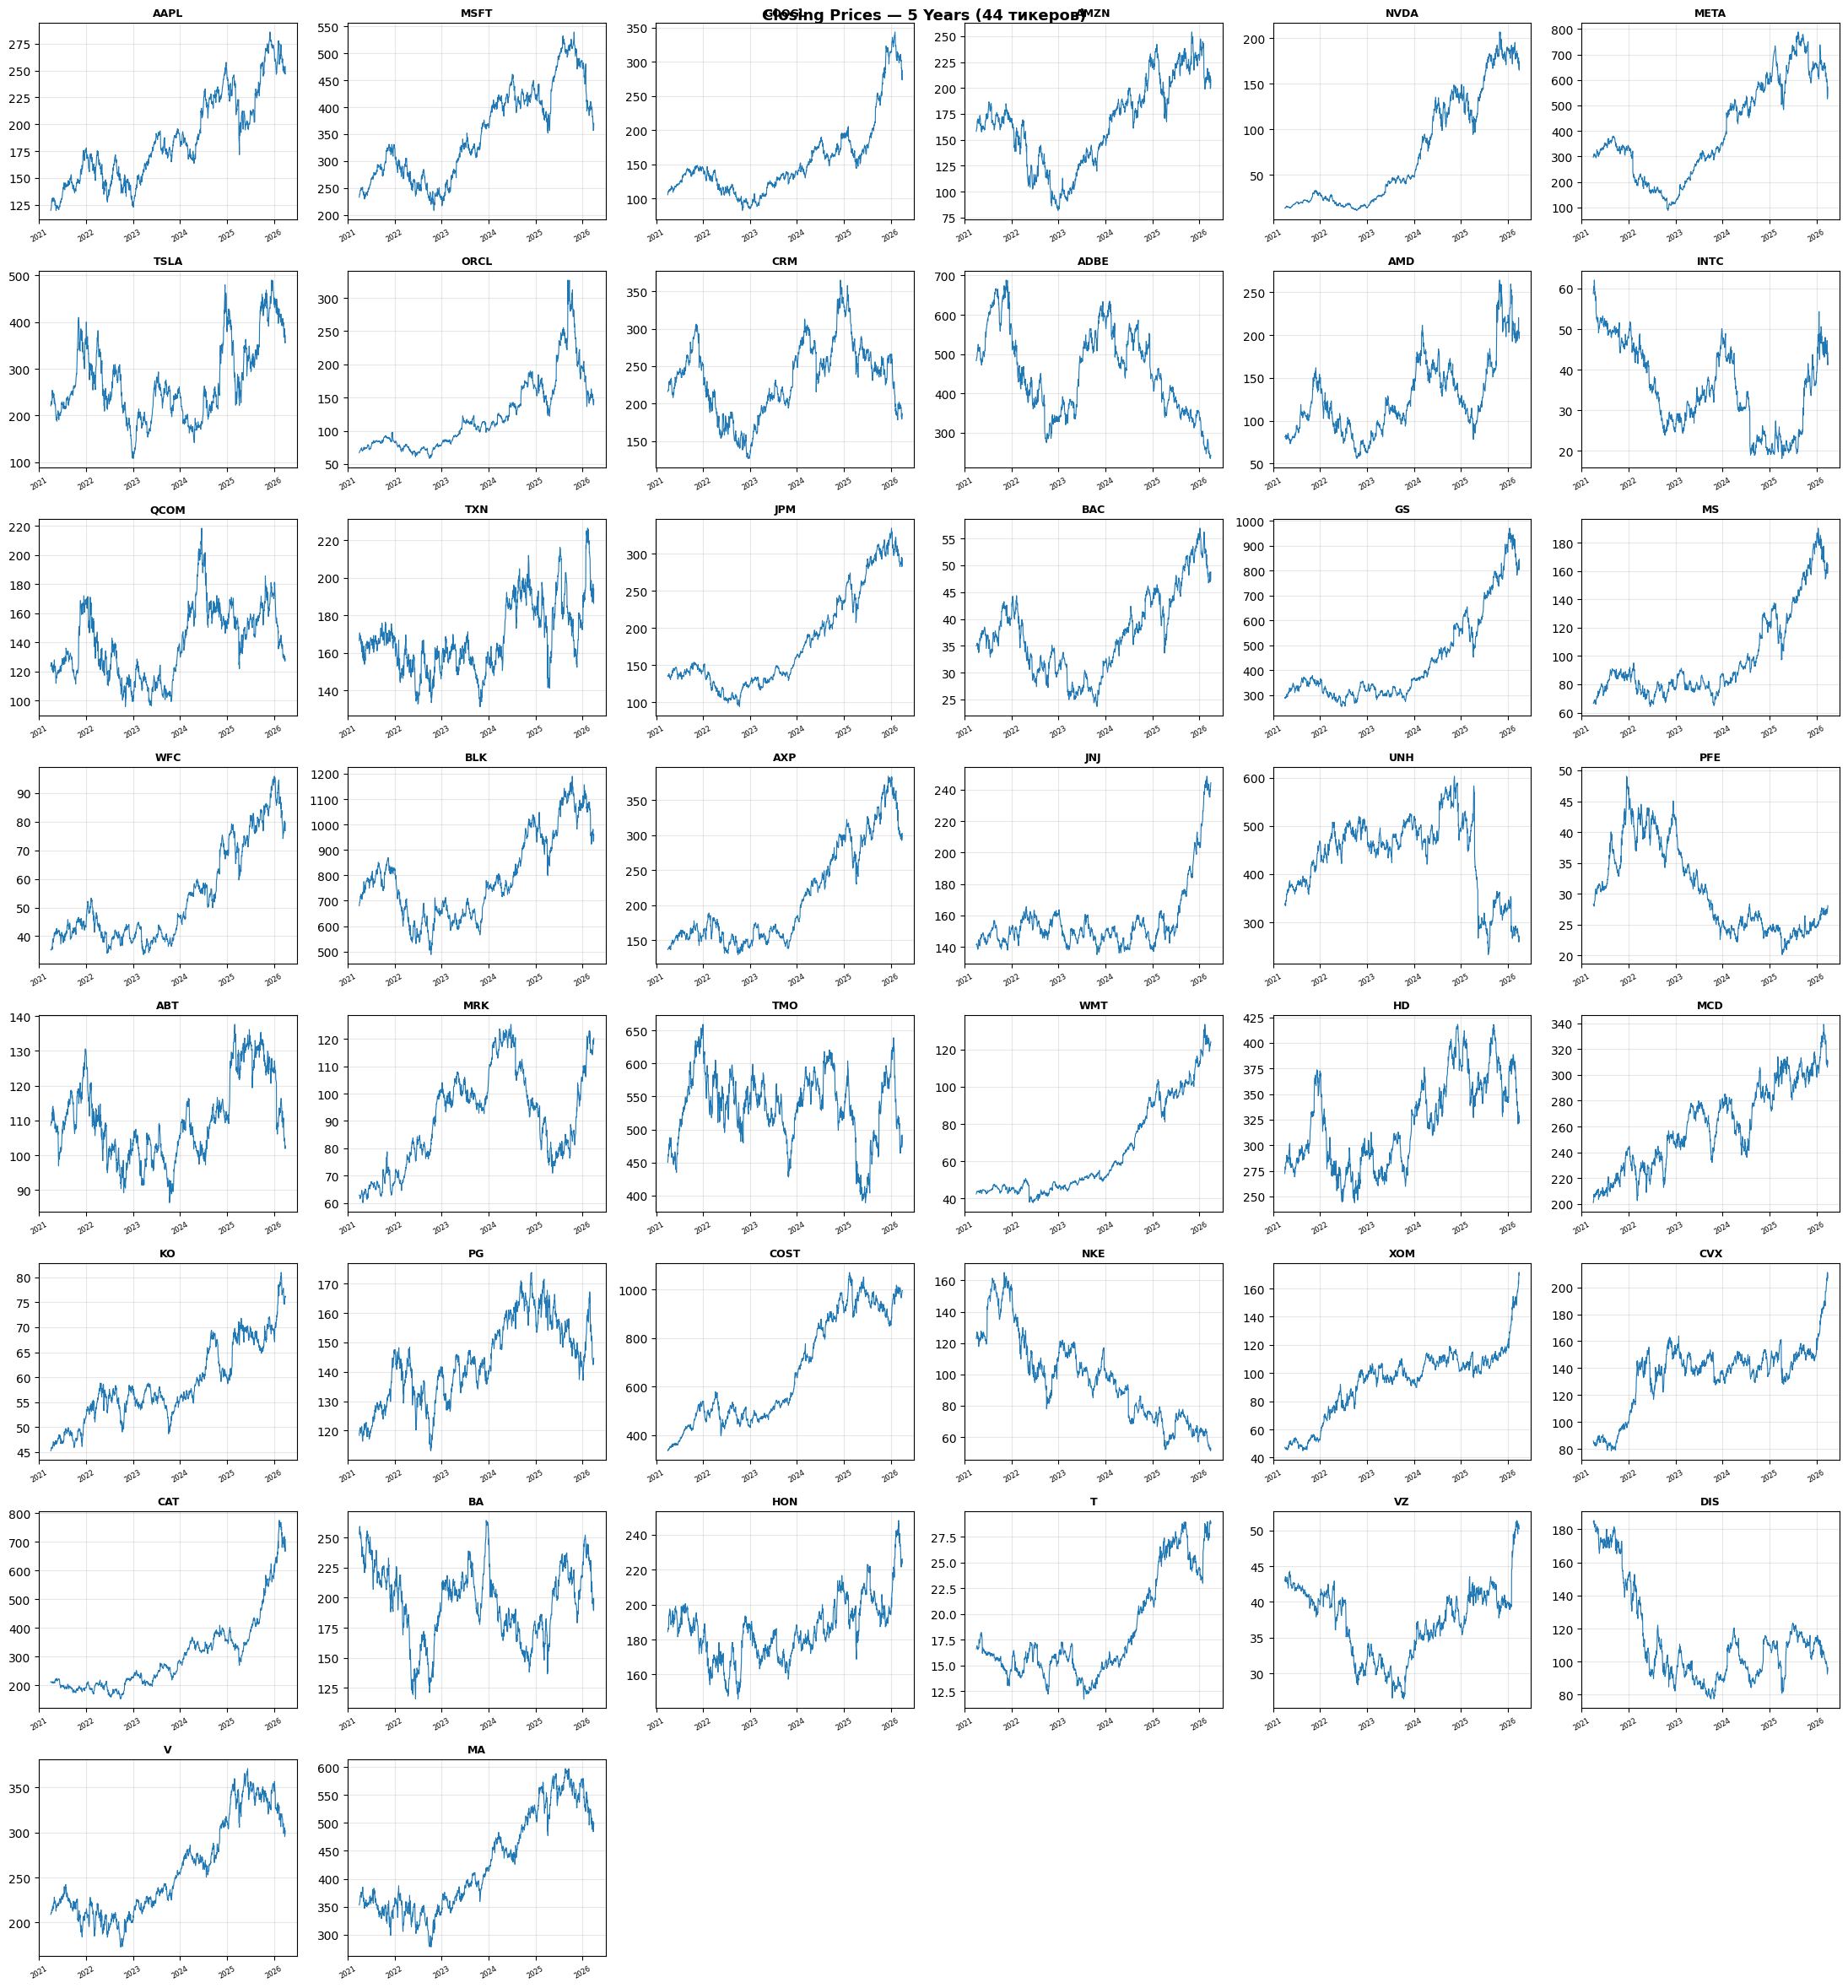

График сохранён в data/raw/prices_overview.png


In [12]:
import matplotlib.pyplot as plt
import math

n = len(ohlcv_data)
n_cols = 6
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3))
axes = axes.flatten()

for i, (ticker, df) in enumerate(ohlcv_data.items()):
    ax = axes[i]
    ax.plot(df.index, df["close"], linewidth=0.8)
    ax.set_title(ticker, fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=6)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Closing Prices — 5 Years ({n} тикеров)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RAW_DIR / "prices_overview.png", dpi=100)
plt.show()
print("График сохранён в data/raw/prices_overview.png")

## Итог

Что было собрано:

| Файл | Описание |
|---|---|
| `{TICKER}_ohlcv.parquet` | Дневные OHLCV данные за 5 лет |
| `fundamentals.parquet` | P/E, EPS, ROE, Debt/Equity, и др. |
| `news_raw.parquet` | Последние новости по каждому тикеру |

**Следующий шаг:** `02_feature_engineering.ipynb` — вычисление технических индикаторов и sentiment.